### Optimizing Air Travel: A Data-Driven Approach to Flight Delay Analysis and Prediction

### 1) Loading Data And Understanding It :-

In [5]:
import pandas as pd
import numpy as np

In [6]:
plane_data = pd.read_csv('Airline_Delay_Cause.csv')

In [7]:
print("Dataset Shape:", plane_data.shape)
print("\nMissing Values Before Cleaning:\n", plane_data.isnull().sum())
print("\nNon-Standard Missing Values Check:\n", plane_data.isin(['', 'N/A', 'NA', 'null', 'NULL']).sum())
print("\nData Info:\n")
plane_data.info()
print("\nUnique Years:", plane_data['year'].unique())

Dataset Shape: (179338, 21)

Missing Values Before Cleaning:
 year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            341
arr_del15              591
carrier_ct             341
weather_ct             341
nas_ct                 341
security_ct            341
late_aircraft_ct       341
arr_cancelled          341
arr_diverted           341
arr_delay              341
carrier_delay          341
weather_delay          341
nas_delay              341
security_delay         341
late_aircraft_delay    341
dtype: int64

Non-Standard Missing Values Check:
 year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct     

In [8]:
plane_data.dropna(inplace=True)
#dropped the missing rows having missing values

In [9]:
plane_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178747 entries, 0 to 179337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 178747 non-null  int64  
 1   month                178747 non-null  int64  
 2   carrier              178747 non-null  object 
 3   carrier_name         178747 non-null  object 
 4   airport              178747 non-null  object 
 5   airport_name         178747 non-null  object 
 6   arr_flights          178747 non-null  float64
 7   arr_del15            178747 non-null  float64
 8   carrier_ct           178747 non-null  float64
 9   weather_ct           178747 non-null  float64
 10  nas_ct               178747 non-null  float64
 11  security_ct          178747 non-null  float64
 12  late_aircraft_ct     178747 non-null  float64
 13  arr_cancelled        178747 non-null  float64
 14  arr_diverted         178747 non-null  float64
 15  arr_delay            1

### 2) EDA :-

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

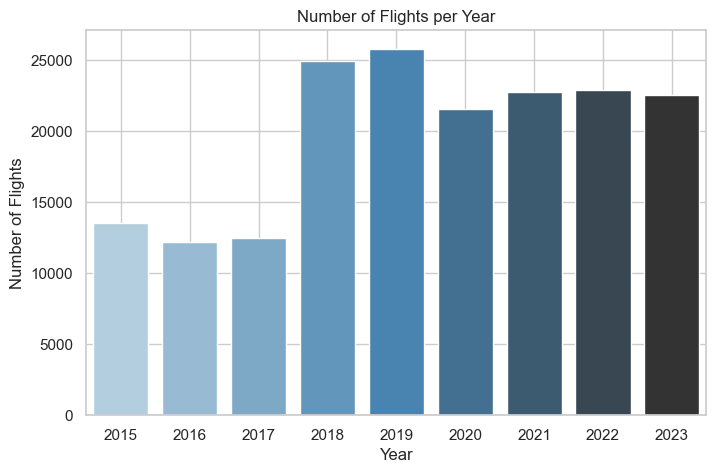

In [12]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(x='year', hue='year', data=plane_data, palette='Blues_d', legend=False)
plt.title('Number of Flights per Year')
plt.xlabel('Year')
plt.ylabel('Number of Flights')
plt.grid(True)
plt.show()

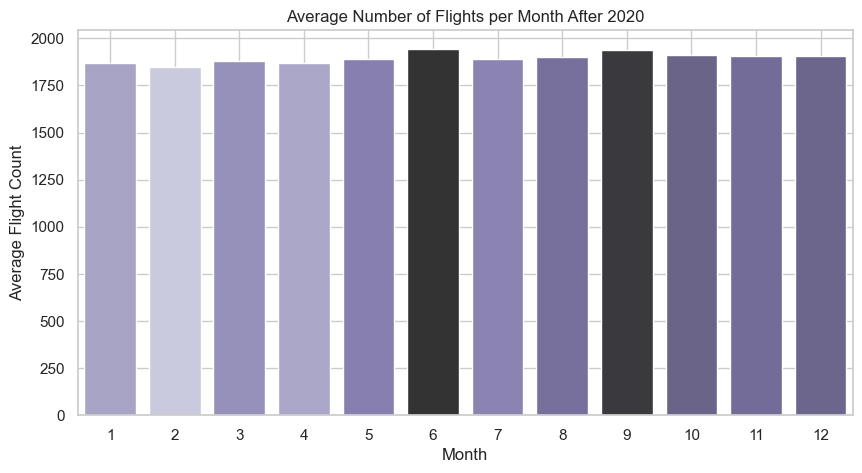

In [13]:
# Older flight data may not reflect current trends due to major changes (e.g., COVID-19).
# Therefore, am filtering for data after 2020 and plot the average number of flights per month.

# Filter data for flights after 2020
filtered_data = plane_data[plane_data['year'] > 2020]

monthly_avg = (
    filtered_data.groupby(['year', 'month']).size()  # Get monthly flight counts for each year
    .groupby('month')  # Group by month across years
    .mean()  # Average over the years
    .reset_index(name='flight_count')
)
# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='flight_count', data=monthly_avg, palette='Purples_d',hue = 'flight_count', legend = False)
plt.title('Average Number of Flights per Month After 2020')
plt.xlabel('Month')
plt.ylabel('Average Flight Count')
plt.grid(True)
plt.show()

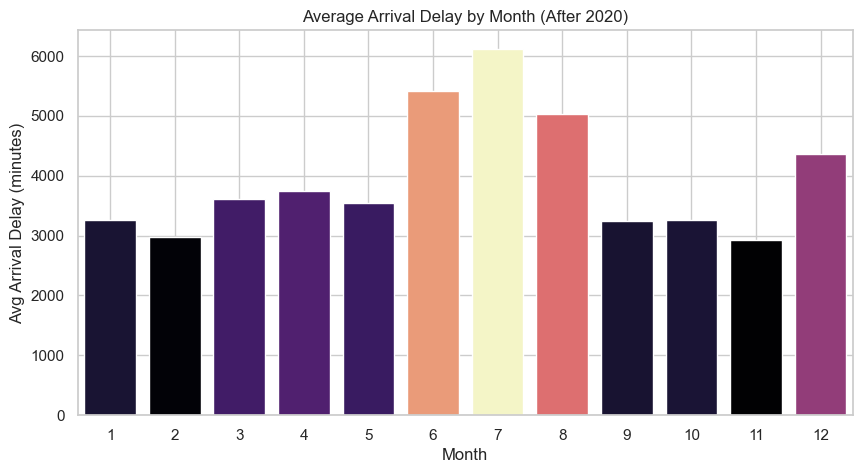

In [14]:
# Showing average arrival delay by month after 2020 to reflect recent trends only.
# Older data may not be relevant due to major disruptions and industry changes.

# Filter data for flights after 2020
filtered_data = plane_data[plane_data['year'] > 2020]

# Calculate average arrival delay per month
monthly_delay = (
    filtered_data.groupby('month')['arr_delay']
    .mean()
    .reset_index(name='avg_arr_delay')
)

# Sort by month if it's numeric
monthly_delay = monthly_delay.sort_values('month')

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='avg_arr_delay', data=monthly_delay, palette='magma',hue = 'avg_arr_delay', legend = False)
plt.title('Average Arrival Delay by Month (After 2020)')
plt.xlabel('Month')
plt.ylabel('Avg Arrival Delay (minutes)')
plt.grid(True)
plt.show()

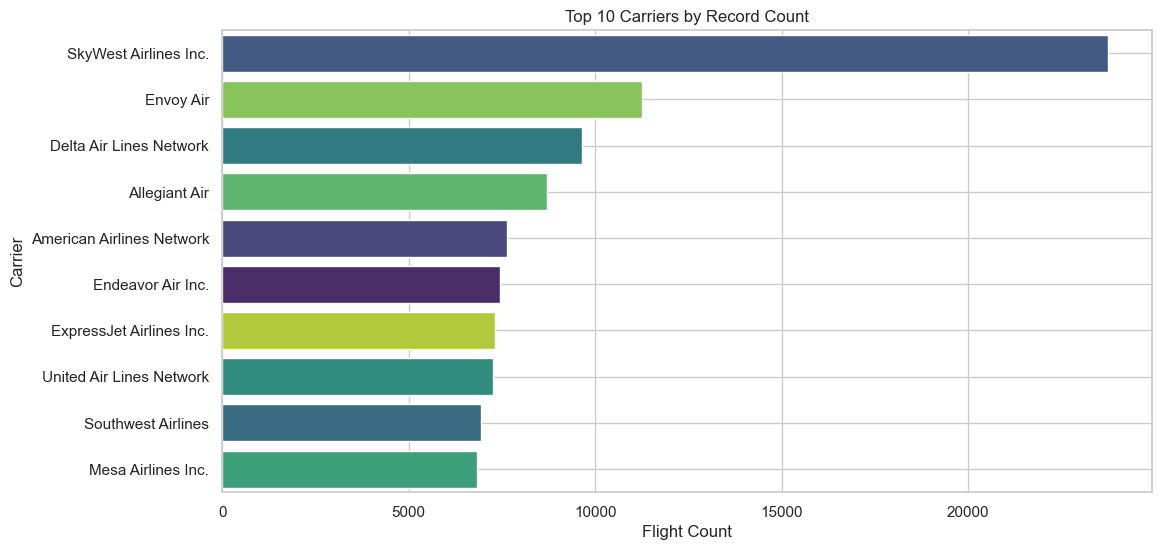

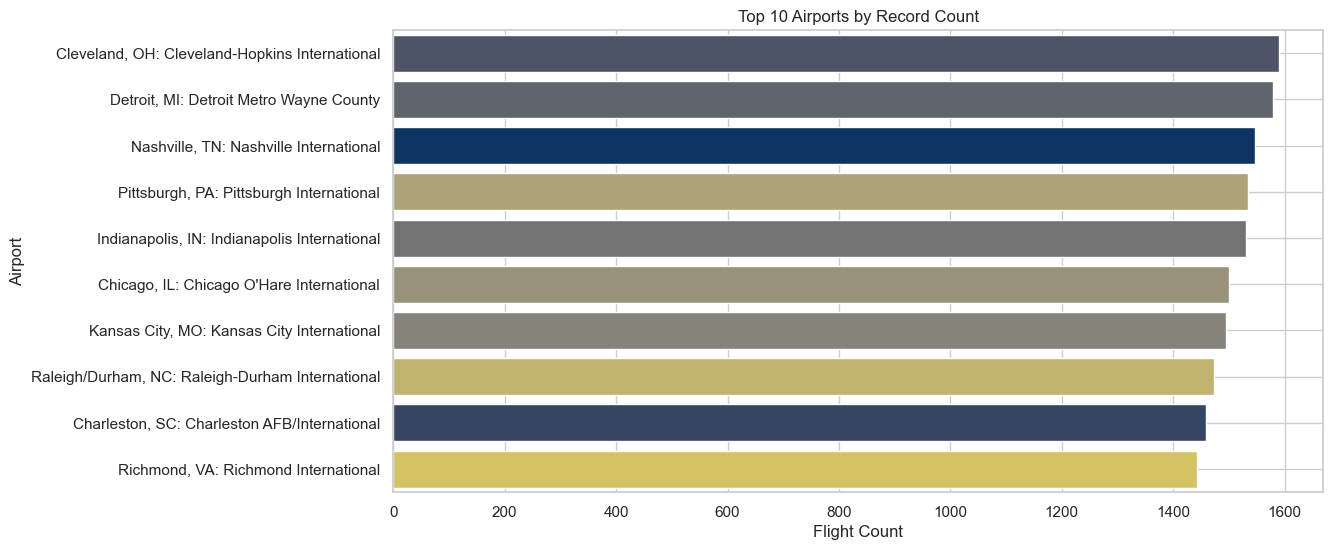

In [15]:
# Top 10 carriers by flight count
top_carriers = plane_data['carrier_name'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(y='carrier_name', data=plane_data[plane_data['carrier_name'].isin(top_carriers)],
              order=top_carriers,hue='carrier_name',legend=False, palette='viridis')
plt.title('Top 10 Carriers by Record Count')
plt.xlabel('Flight Count')
plt.ylabel('Carrier')
plt.grid(True)
plt.show()

# Top 10 airports by flight count
top_airports = plane_data['airport_name'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(y='airport_name', data=plane_data[plane_data['airport_name'].isin(top_airports)],
              order=top_airports,hue='airport_name',legend=False, palette='cividis')
plt.title('Top 10 Airports by Record Count')
plt.xlabel('Flight Count')
plt.ylabel('Airport')
plt.grid(True)
plt.show()

In [16]:
# Numerical Columns Univariate Analysis

num_cols = [
    'arr_flights', 'arr_del15', 'arr_delay',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    'arr_cancelled', 'arr_diverted'
]

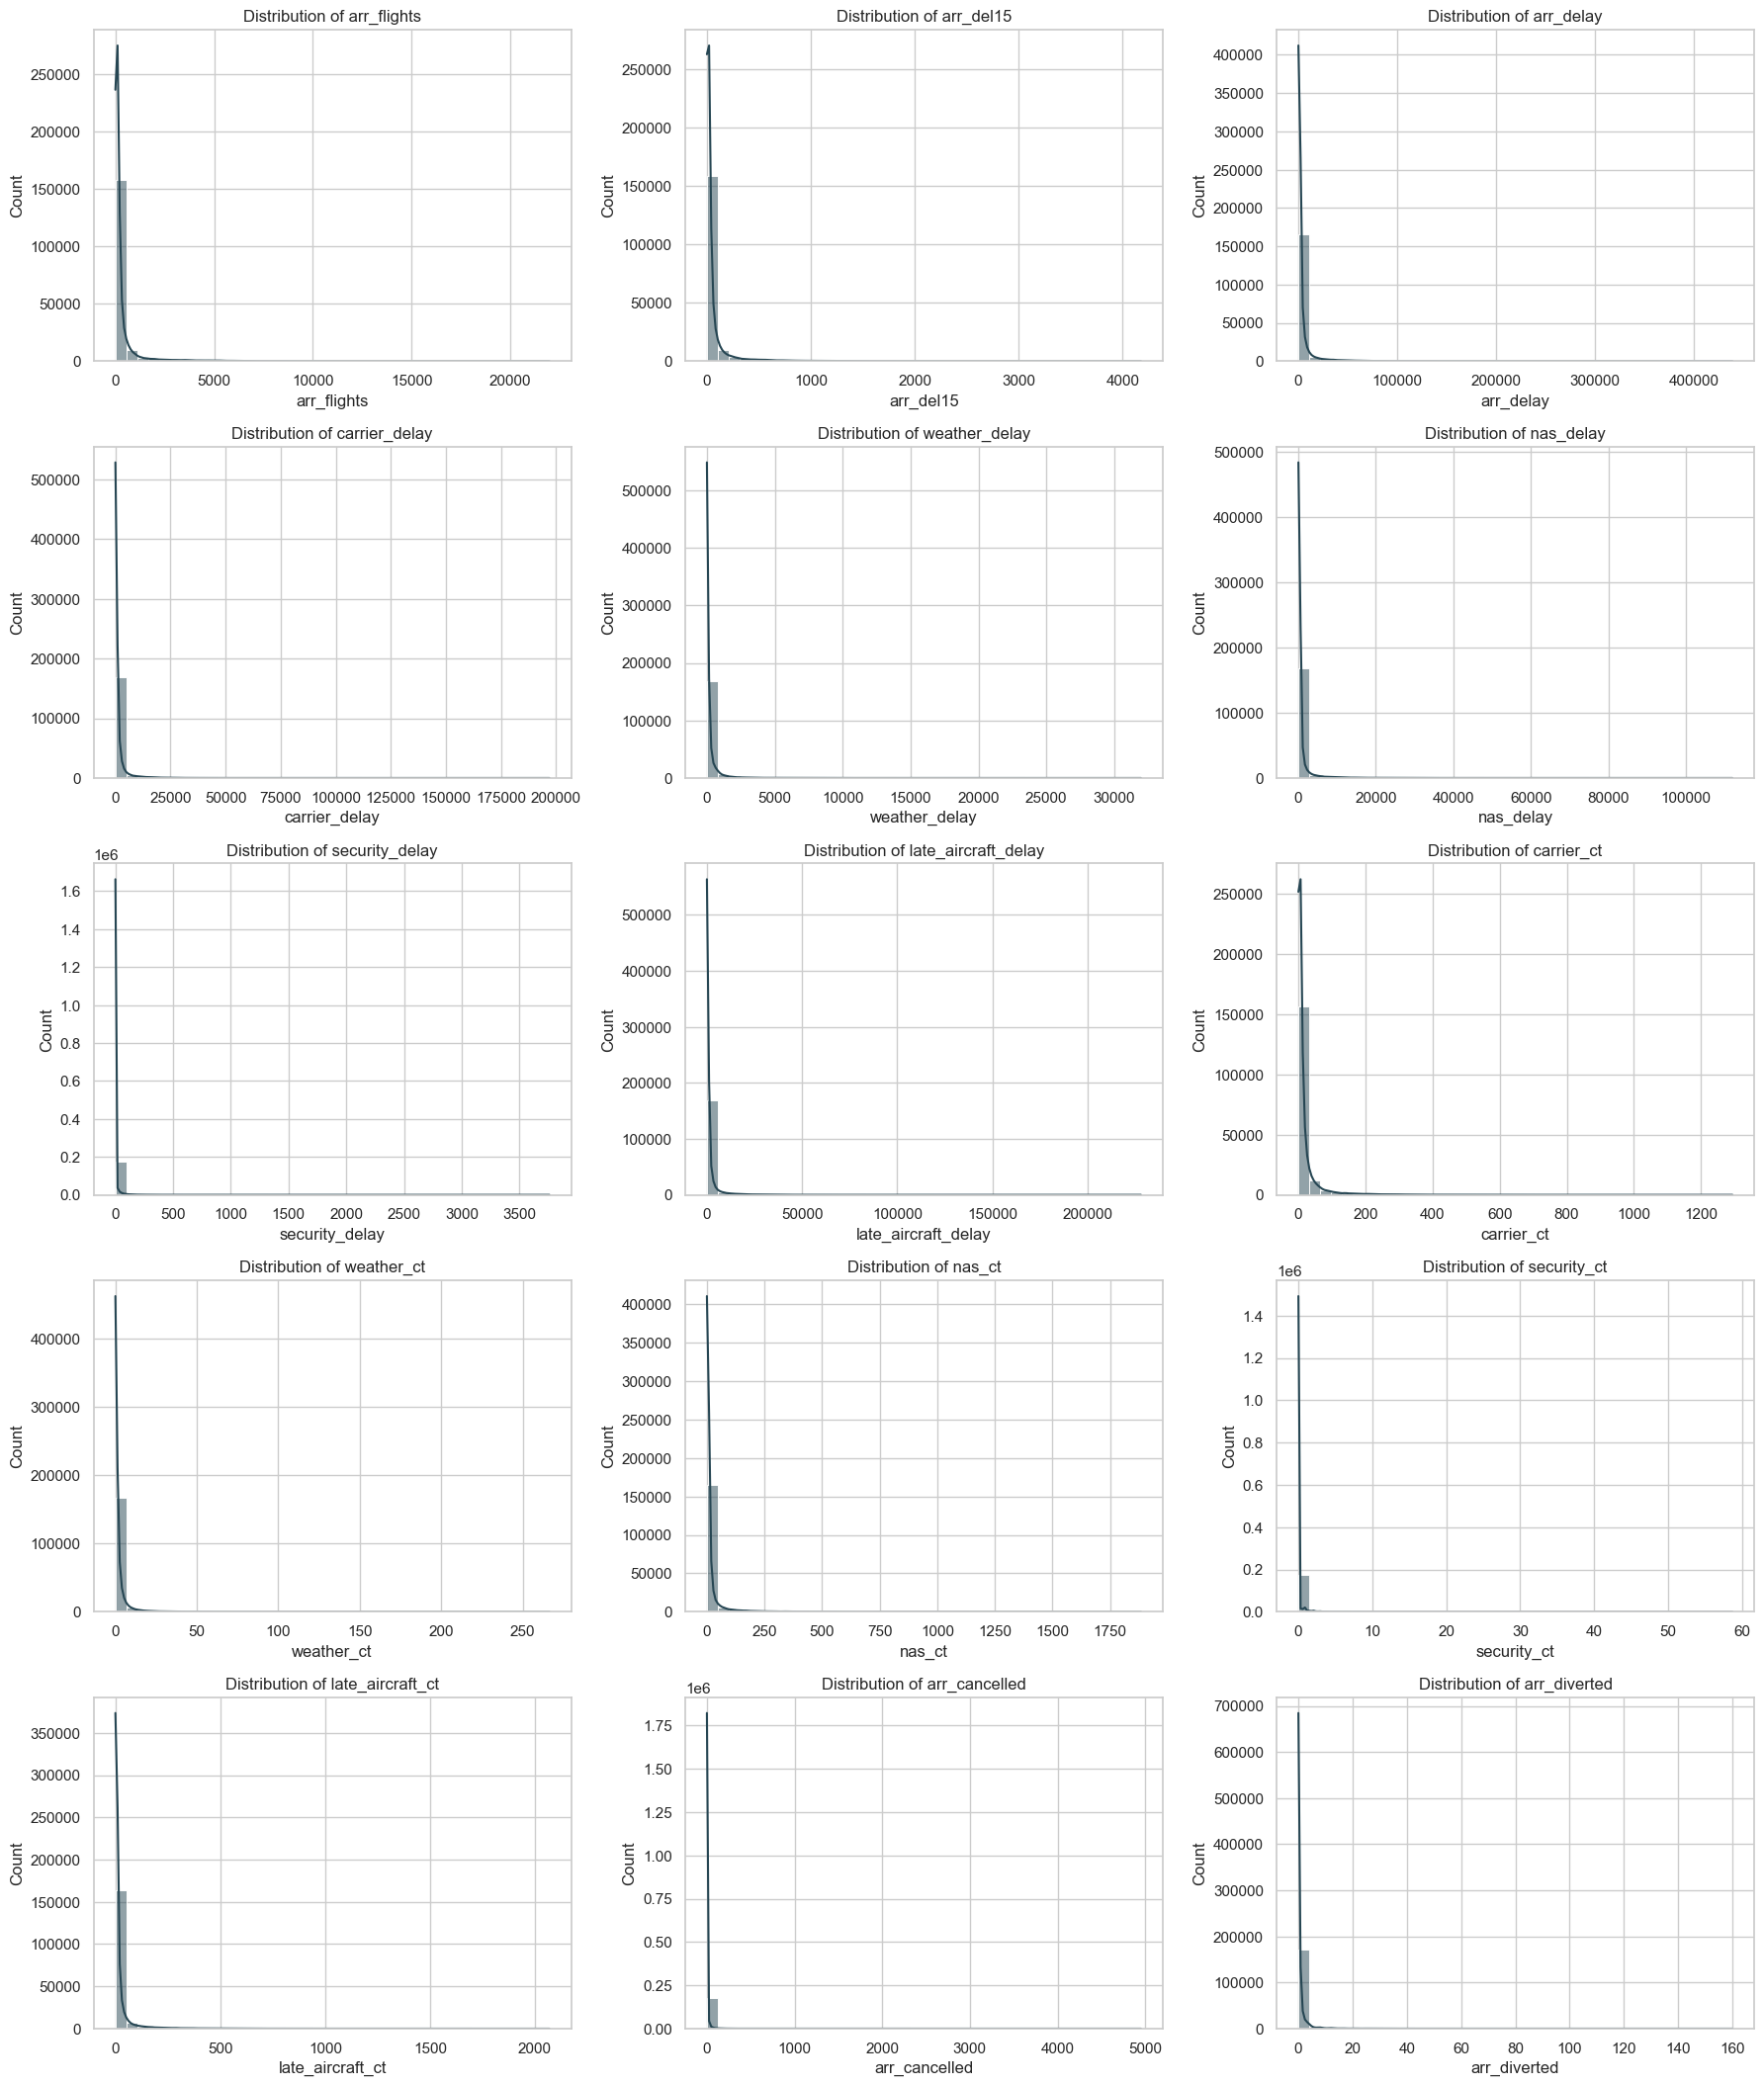

In [17]:
plt.figure(figsize=(18, 25))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 3, i)
    sns.histplot(plane_data[col], bins=40, kde=True, color='#264653')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

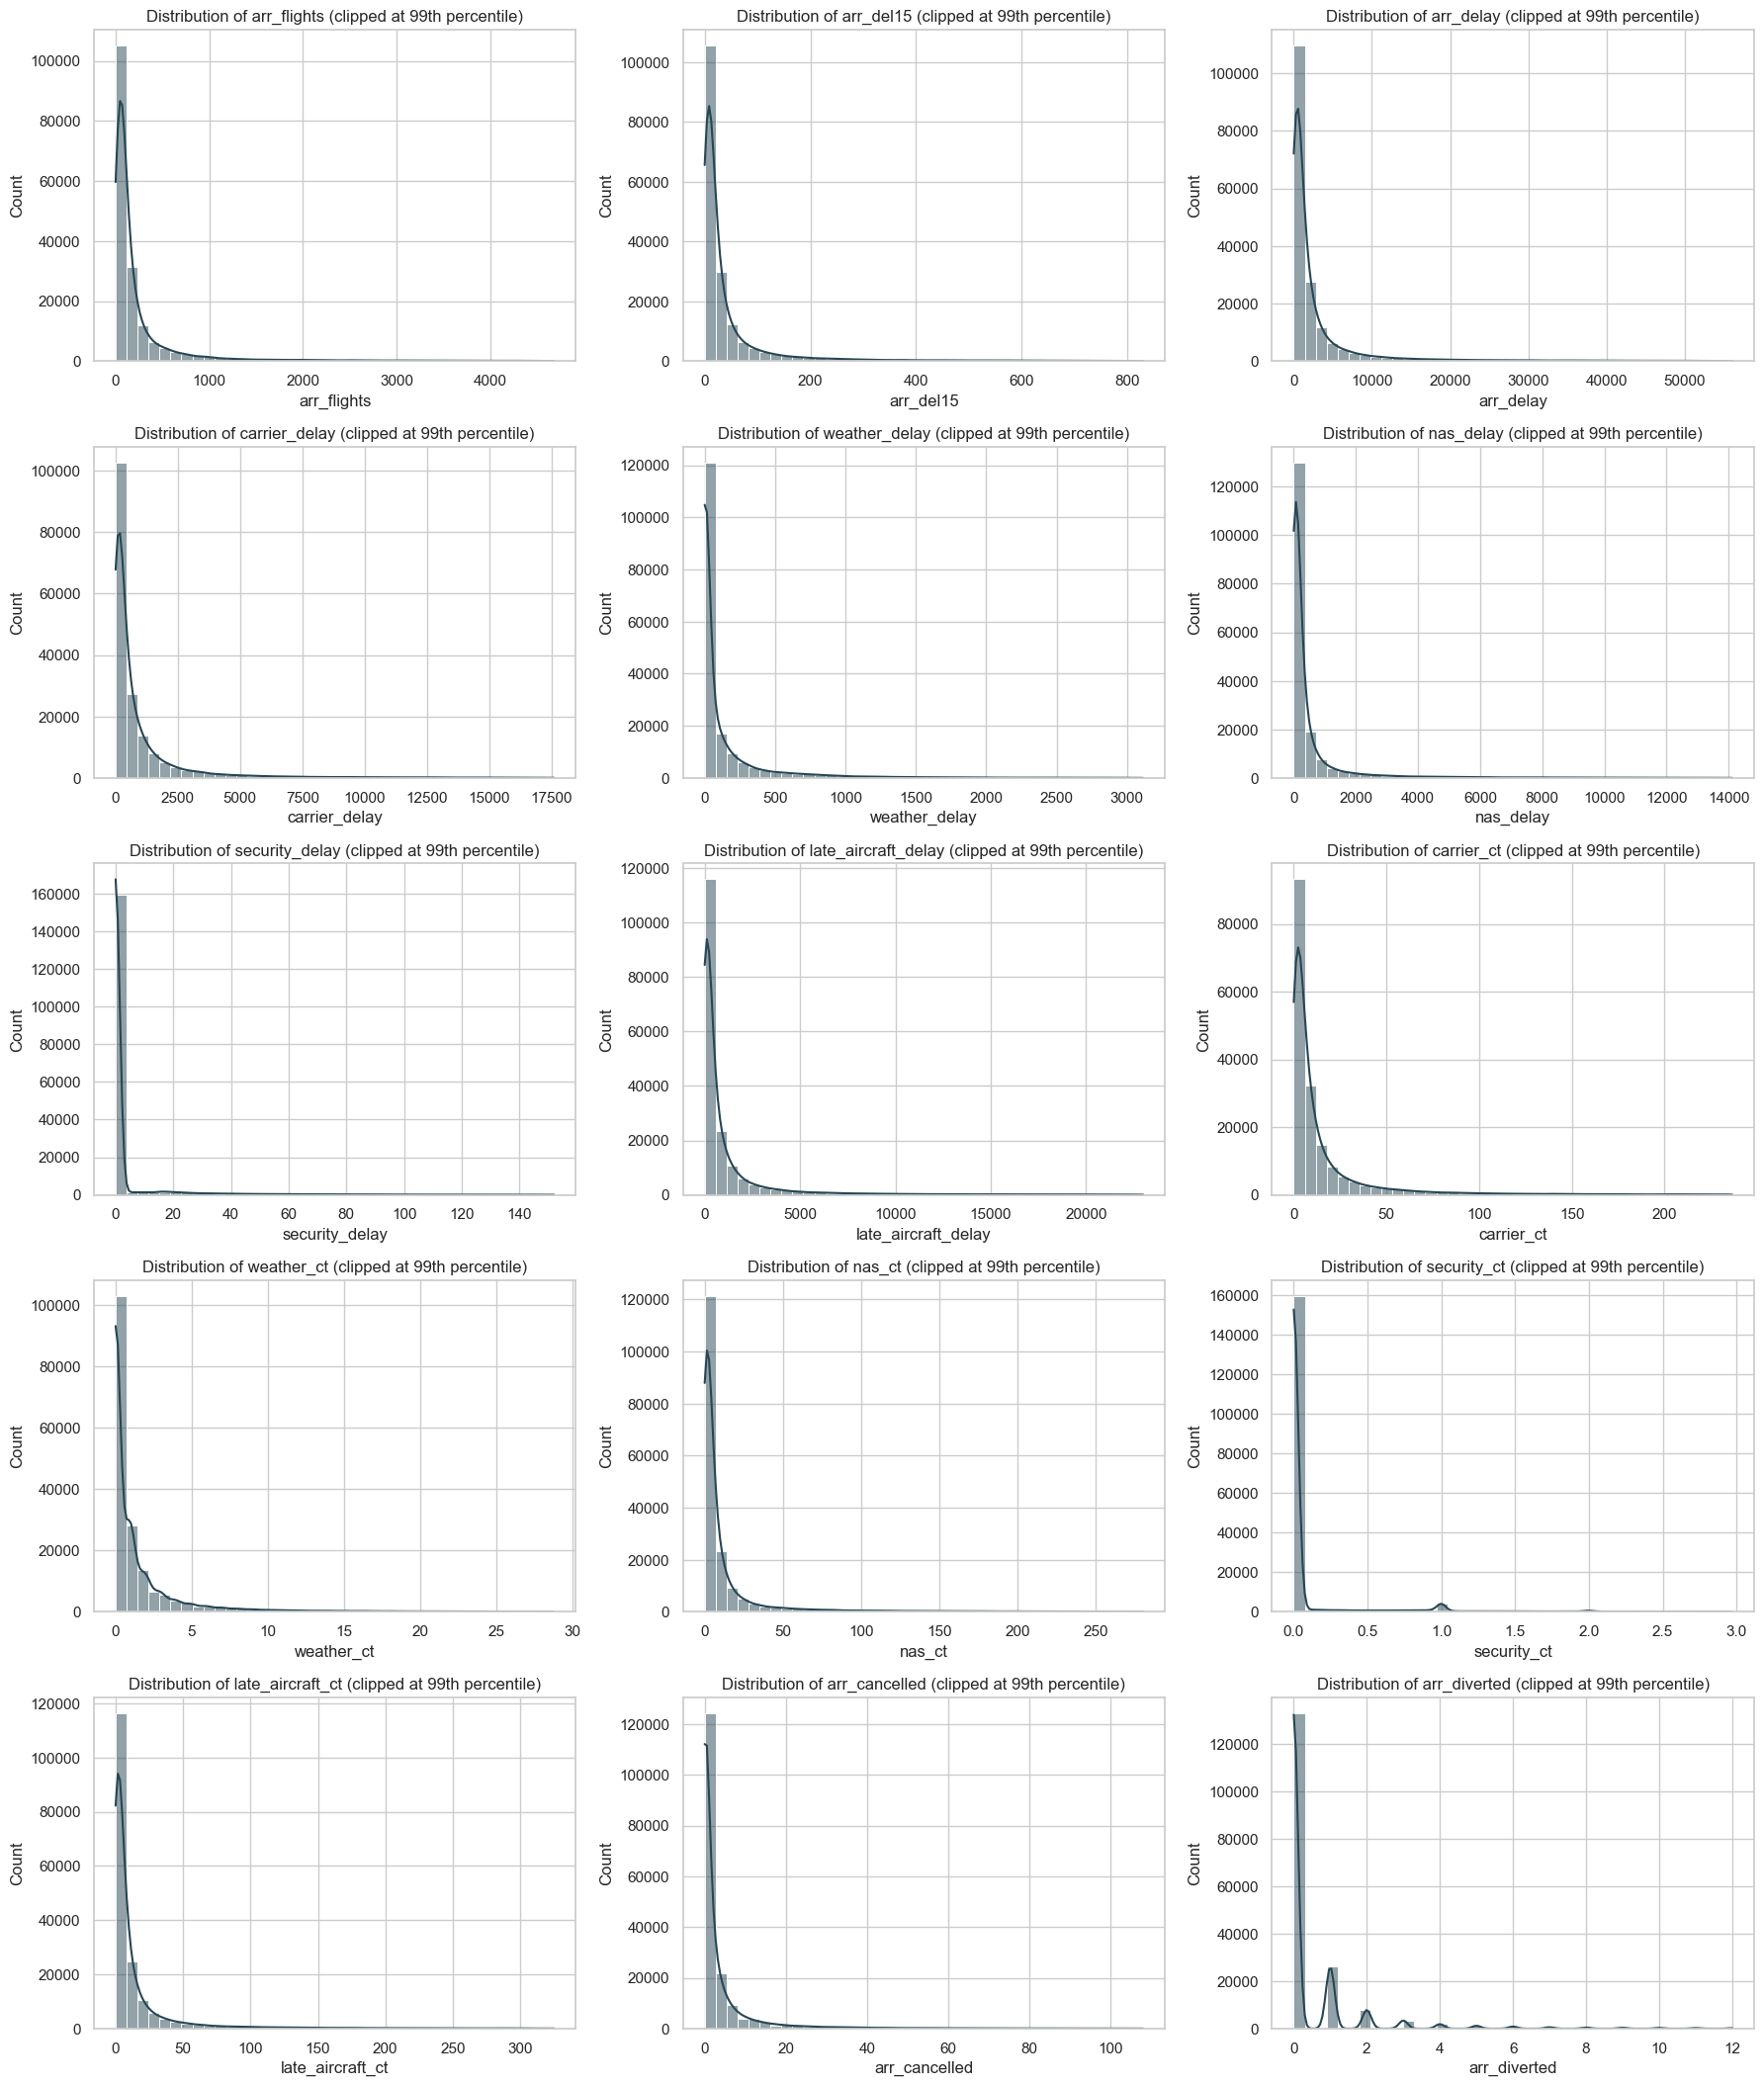

In [18]:
plt.figure(figsize=(18, 25))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 3, i)
    
    # Calculate 99th percentile to limit x-axis
    x_max = np.percentile(plane_data[col].dropna(), 99)
    
    # Plot histogram clipped at 99th percentile for better visualization
    sns.histplot(plane_data[plane_data[col] <= x_max][col], bins=40, kde=True, color='#264653')
    
    plt.title(f'Distribution of {col} (clipped at 99th percentile)')
plt.tight_layout()
plt.show()

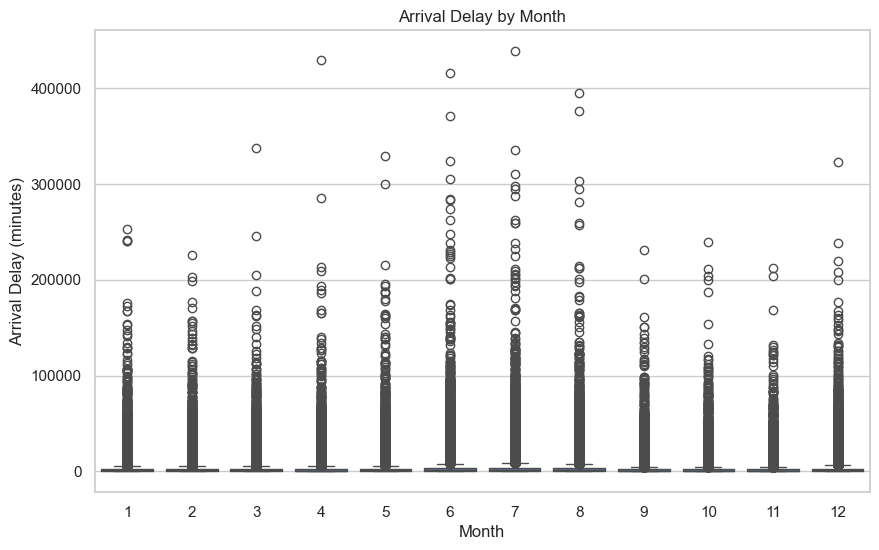

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='arr_delay', data=plane_data)
plt.title('Arrival Delay by Month')
plt.ylabel('Arrival Delay (minutes)')
plt.xlabel('Month')
plt.show()

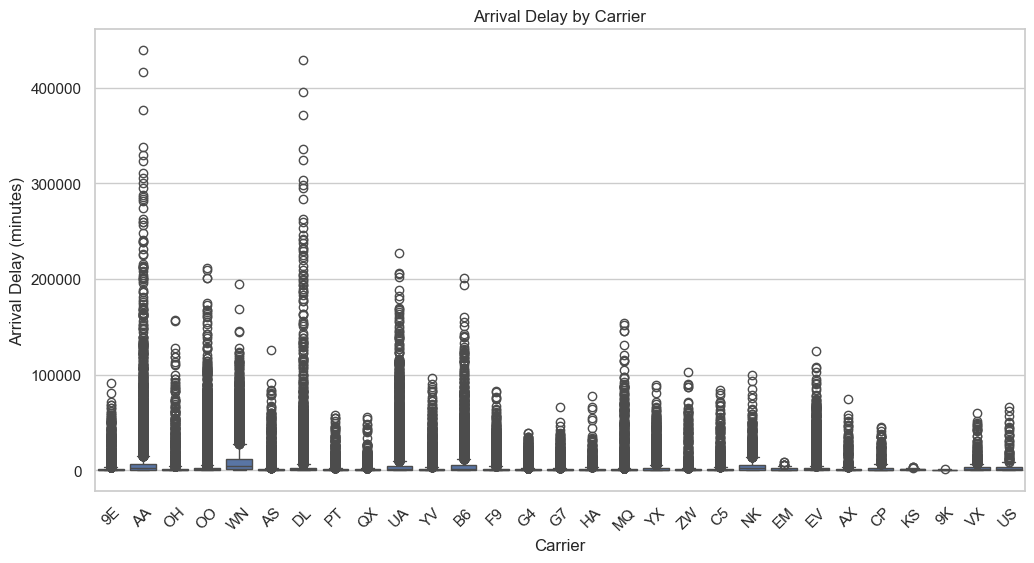

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='carrier', y='arr_delay', data=plane_data)
plt.title('Arrival Delay by Carrier')
plt.ylabel('Arrival Delay (minutes)')
plt.xlabel('Carrier')
plt.xticks(rotation=45)
plt.show()

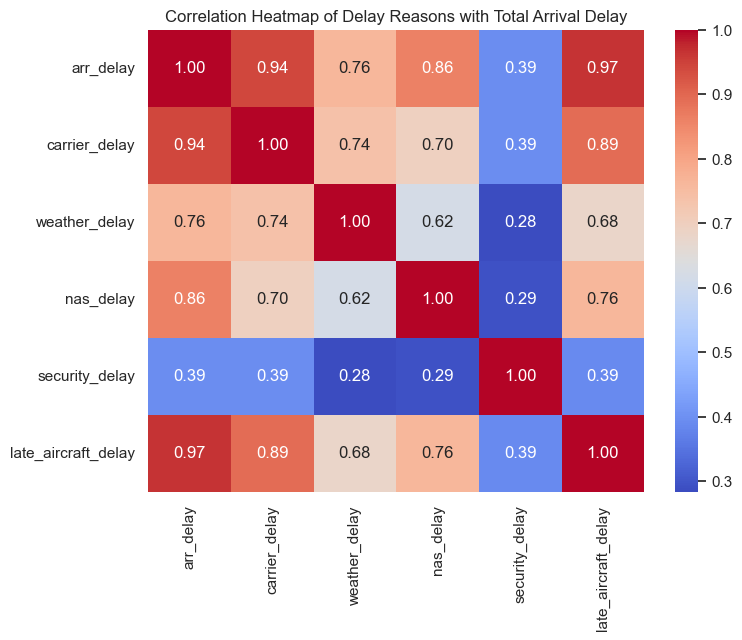

In [21]:
delay_cols = [
    'arr_delay', 'carrier_delay', 'weather_delay', 
    'nas_delay', 'security_delay', 'late_aircraft_delay'
]

# Computing correlation matrix
corr = plane_data[delay_cols].corr()

# Ploting heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Delay Reasons with Total Arrival Delay')
plt.show()

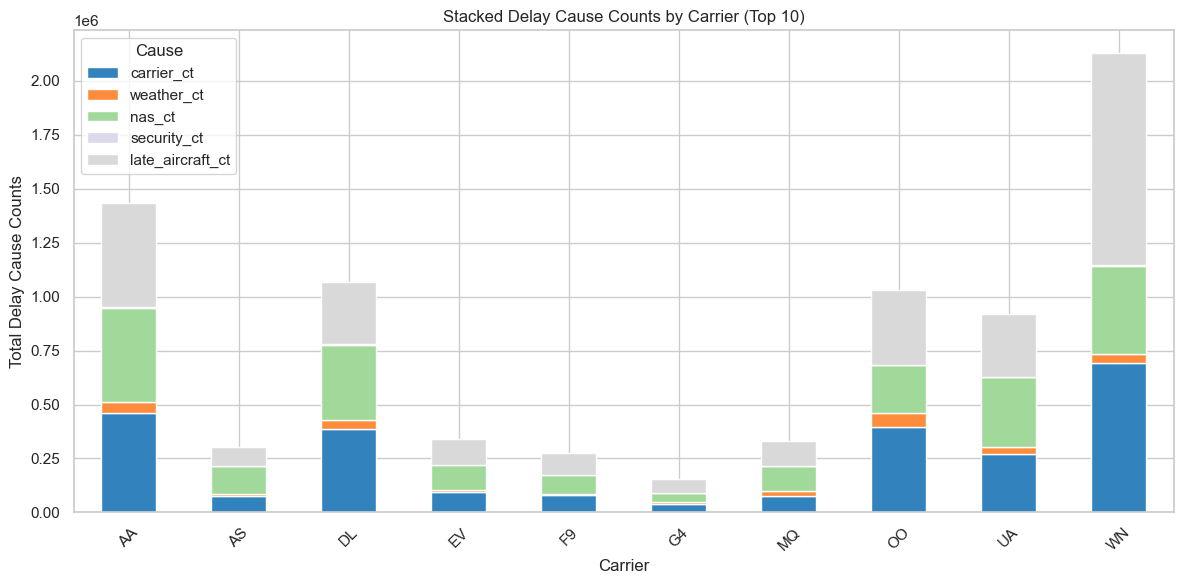

In [22]:
#filtering top 10 carriers by frequency
top_carriers = plane_data['carrier'].value_counts().nlargest(10).index
plane_data_top_carriers = plane_data[plane_data['carrier'].isin(top_carriers)]

# Grouping by carrier and sum cause counts
delay_causes = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
grouped = plane_data_top_carriers.groupby('carrier')[delay_causes].sum()

# Ploting stacked bar
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20c')
plt.title('Stacked Delay Cause Counts by Carrier (Top 10)')
plt.ylabel('Total Delay Cause Counts')
plt.xlabel('Carrier')
plt.xticks(rotation=45)
plt.legend(title='Cause')
plt.tight_layout()
plt.show()

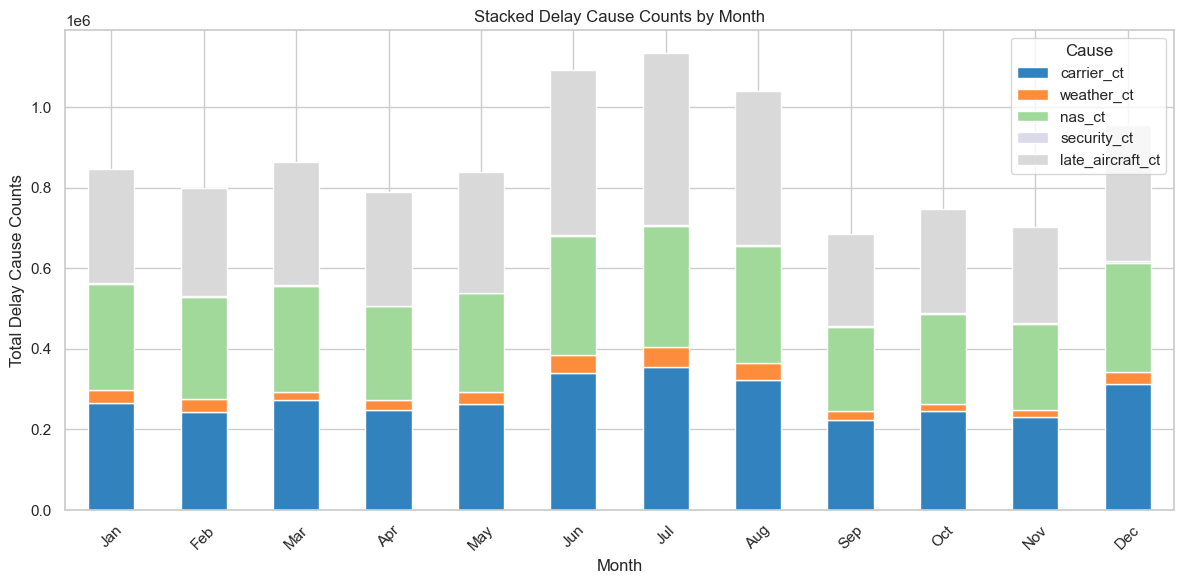

In [23]:
# Ensure month is in numeric form (1–12), or convert to month names if preferred
delay_causes = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

# Group by month and sum delay cause counts
grouped_by_month = plane_data.groupby('month')[delay_causes].sum().sort_index()

# Optional: Convert month numbers to names for x-axis
import calendar
grouped_by_month.index = [calendar.month_abbr[m] for m in grouped_by_month.index]

# Plot stacked bar chart
grouped_by_month.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20c')
plt.title('Stacked Delay Cause Counts by Month')
plt.ylabel('Total Delay Cause Counts')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Cause')
plt.tight_layout()
plt.show()

In [24]:
plane_data['delay_label'] = (plane_data['arr_del15'] > 0).astype(int)

Class Distribution:
delay_label
1    170374
0      8373
Name: count, dtype: int64

Percentage Distribution:
delay_label
1    95.32
0     4.68
Name: count, dtype: float64


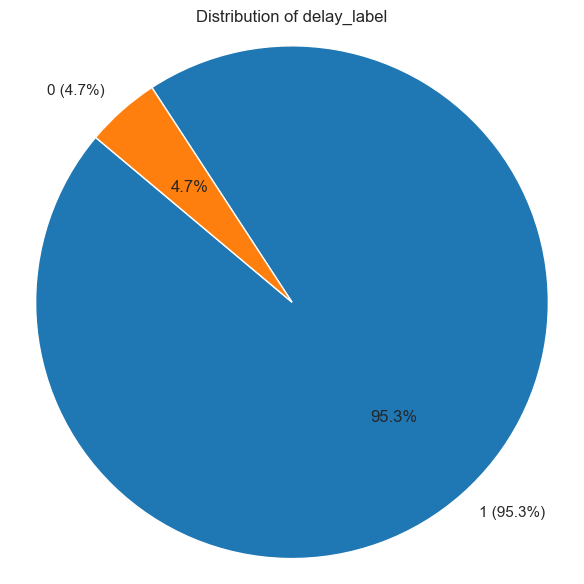

In [25]:
column_name = 'delay_label' 

# Count class distribution
value_counts = plane_data[column_name].value_counts()
percentages = value_counts / value_counts.sum() * 100

print("Class Distribution:")
print(value_counts)
print("\nPercentage Distribution:")
print(percentages.round(2))

# Ploting pie chart
colors = ['#1f77b4', '#ff7f0e']  # Custom hex colors for the pie chart
labels = [f'{cls} ({pct:.1f}%)' for cls, pct in zip(value_counts.index, percentages)]

plt.figure(figsize=(6, 6))
plt.pie(value_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title(f'Distribution of {column_name}')
plt.axis('equal')  # Equal aspect ratio ensures a perfect circle
plt.tight_layout()

# Save the plot
plt.savefig(f'{column_name}_distribution_piechart.png')
plt.show()

In [26]:
# data is highly imbalance

### 3) Feature Engineering

In [28]:
# Season: Converting month to season (Winter, Spring, etc.)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

plane_data['season'] = plane_data['month'].apply(get_season)

In [29]:
# Add cyclical features
plane_data['month_sin'] = np.sin(2 * np.pi * plane_data['month'] / 12)
plane_data['month_cos'] = np.cos(2 * np.pi * plane_data['month'] / 12)

# Then drop month (after cyclical encoding)
plane_data = plane_data.drop(columns=['month'])

### 4) Pre-Processing

In [31]:
columns_to_drop = ['carrier_name', 'airport_name']
plane_data_cleaned = plane_data.drop(columns=columns_to_drop)
#since we already have their code

In [32]:
plane_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178747 entries, 0 to 179337
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 178747 non-null  int64  
 1   carrier              178747 non-null  object 
 2   airport              178747 non-null  object 
 3   arr_flights          178747 non-null  float64
 4   arr_del15            178747 non-null  float64
 5   carrier_ct           178747 non-null  float64
 6   weather_ct           178747 non-null  float64
 7   nas_ct               178747 non-null  float64
 8   security_ct          178747 non-null  float64
 9   late_aircraft_ct     178747 non-null  float64
 10  arr_cancelled        178747 non-null  float64
 11  arr_diverted         178747 non-null  float64
 12  arr_delay            178747 non-null  float64
 13  carrier_delay        178747 non-null  float64
 14  weather_delay        178747 non-null  float64
 15  nas_delay            1

In [33]:
# List of categorical columns to encode
categorical_cols = ['airport', 'carrier', 'season', 'year']

# One-hot encode all
plane_data_encoded = pd.get_dummies(plane_data_cleaned, columns=categorical_cols, drop_first=True)


In [34]:
plane_data_encoded.head()

,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,...,season_Summer,season_Winter,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023
0,72.0,5.0,2.46,1.00,0.73,0.0,0.81,0.0,0.0,672.0,...,False,True,False,False,False,False,False,False,False,True
1,62.0,7.0,4.25,0.00,1.00,0.0,1.75,0.0,0.0,348.0,...,False,True,False,False,False,False,False,False,False,True
2,95.0,10.0,5.94,0.00,1.06,0.0,3.00,0.0,0.0,859.0,...,False,True,False,False,False,False,False,False,False,True
3,23.0,2.0,0.56,0.00,0.00,0.0,1.44,1.0,0.0,75.0,...,False,True,False,False,False,False,False,False,False,True
4,2111.0,256.0,76.88,8.75,52.43,0.0,117.94,1.0,0.0,21424.0,...,False,True,False,False,False,False,False,False,False,True


In [35]:
bool_cols = plane_data_encoded.select_dtypes(include='bool').columns
plane_data_encoded[bool_cols] = plane_data_encoded[bool_cols].astype(int)

### 5) Modeling AND OAI

In [37]:
# These are my engineered/encoded month features
base_cols = ['month_sin', 'month_cos']

# Grab all one-hot encoded columns that start with year_, carrier_name_, airport_name_, or season_
encoded_cols = [col for col in plane_data_encoded.columns if 
                col.startswith('year_') or
                col.startswith('carrier_') or
                col.startswith('airport_') or
                col.startswith('season_')]

# Combine to form the final X
X = plane_data_encoded[base_cols + encoded_cols]

# Target column
y = plane_data_encoded['delay_label']

In [38]:
X

,month_sin,month_cos,carrier_ct,carrier_delay,airport_ABI,airport_ABQ,airport_ABR,airport_ABY,airport_ACK,airport_ACT,...,season_Summer,season_Winter,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023
0,-2.449294e-16,1.000000,2.46,61.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,-2.449294e-16,1.000000,4.25,252.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,-2.449294e-16,1.000000,5.94,536.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,-2.449294e-16,1.000000,0.56,9.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,-2.449294e-16,1.000000,76.88,8906.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179333,5.000000e-01,0.866025,59.21,2661.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
179334,5.000000e-01,0.866025,18.00,840.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
179335,5.000000e-01,0.866025,25.17,1003.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
179336,5.000000e-01,0.866025,64.00,2370.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Before SMOTE
print("Before SMOTE:", Counter(y_train))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# After SMOTE
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({1: 136299, 0: 6698})
After SMOTE: Counter({1: 136299, 0: 136299})


In [41]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train & evaluate
for name, model in models.items():
    print(f"\n--- {name} ---")

    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    # Save the model
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_classifier.pkl")



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.58      0.97      0.72      1675
           1       1.00      0.96      0.98     34075

    accuracy                           0.97     35750
   macro avg       0.79      0.97      0.85     35750
weighted avg       0.98      0.97      0.97     35750

ROC-AUC Score: 0.9834746619068999

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.59      0.87      0.70      1675
           1       0.99      0.97      0.98     34075

    accuracy                           0.97     35750
   macro avg       0.79      0.92      0.84     35750
weighted avg       0.97      0.97      0.97     35750

ROC-AUC Score: 0.9837945182378641

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.56      0.98      0.72      1675
           1       1.00      0.96      0.98     34075

    accuracy                           0.96  

In [42]:
# Target column for Regression
y_reg = plane_data_encoded['arr_delay']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [43]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define models
regression_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor()
}

# Train & evaluate
for name, model in regression_models.items():
    print(f"\n--- {name} ---")

    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = mean_squared_error(y_test_reg, y_pred, squared=False)
    r2 = r2_score(y_test_reg, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.3f}")

    # Save the model
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_regressor.pkl")



--- Random Forest ---
MAE: 811.55
RMSE: 2644.98
R² Score: 0.947

--- XGBoost ---
MAE: 806.80
RMSE: 2764.33
R² Score: 0.942


In [44]:
#tested with log to get rid of outliers but it didnt create that much difference with the result(deleted that code to not make it messy)

In [45]:
y_pred = model.predict(X_test_reg)

In [46]:
import joblib

rf_clf = joblib.load("random_forest_classifier.pkl")
rf_reg = joblib.load("random_forest_regressor.pkl")


In [47]:
controllable_cols = ['carrier_delay', 'late_aircraft_delay']
uncontrollable_cols = ['weather_delay', 'nas_delay', 'security_delay']


In [48]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# ----------------------
# STEP 1: Defining weights for OAI
# ----------------------
oai_weights = {
    'carrier_delay': 1.0,
    'late_aircraft_delay': 1.0,
    'weather_delay': 0.2,
    'nas_delay': 0.2,
    'security_delay': 0.2
}

# ----------------------
# STEP 2: Defining OAI computation function
# ----------------------
def compute_oai_score(df, predicted_delay, weight_dict):
    df = df.copy()
    df['predicted_delay'] = predicted_delay

    # Actual OAI: weighted sum of actual delay causes
    df['actual_oai'] = sum(df[col] * weight_dict[col] for col in weight_dict)

    # Avoiding division by zero in ratio calculations
    total_actual = df[list(weight_dict.keys())].sum(axis=1).replace(0, 1e-6)
    ratios = df[list(weight_dict.keys())].div(total_actual, axis=0)

    # Predicted OAI: using ratios to distribute predicted delay across causes
    df['predicted_oai'] = (ratios.multiply(predicted_delay, axis=0) * pd.Series(weight_dict)).sum(axis=1)

    # Final OAI metric
    oai_mae = mean_absolute_error(df['actual_oai'], df['predicted_oai'])

    return oai_mae, df[['actual_oai', 'predicted_oai']]

# ----------------------
# STEP 3: Extract test set delay causes (for same rows as X_test_reg)
# ----------------------
# plane_data_encoded must contain delay cause columns for the test set
delay_cols = ['carrier_delay', 'late_aircraft_delay', 'weather_delay', 'nas_delay', 'security_delay']
df_test_extra = plane_data_encoded.loc[X_test_reg.index, delay_cols].copy()

# ----------------------
# STEP 4: Compute OAI score
# ----------------------
oai_mae, oai_df = compute_oai_score(df_test_extra, y_pred, oai_weights)

print(f"\n🔍 OAI MAE (controllable-delay-focused error): {oai_mae:.2f}")



🔍 OAI MAE (controllable-delay-focused error): 620.69


In [49]:
# SHAP WAS MAKING THE JUPYTER NOTEBOOK CRAS AND ALSO TAKING A LOT OF TIME, EVEN I HAVE WAITED FOR MORE THAN 30 MINS BUT STILL IT WAS LOADING.